In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import roc_auc_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import kstest

In [40]:
df = pd.read_csv('new_one.csv')

In [41]:
def heteroskedasticity_test(model):
    _, pval, _, _ = het_breuschpagan(model.resid, model.model.exog)
    print(f"p-value = {pval}")
    
    if pval < 0.05:
        print("Heteroskedasticity\n")
    else:
        print("Homoscedasticity\n")

def linearity_test(model):
    _, pval = sm.stats.linear_rainbow(model)
    print(f"p-value = {pval}")
    
    if pval < 0.05:
        print("Bad linearity\n")
    else:
        print("Good linearity\n")

def durbin_watson_test(model):
    dw_stat = durbin_watson(model.resid)
    print(f"DW = {dw_stat}")
    if dw_stat < 1.5:
        print("Positive\n")
    elif dw_stat > 2.5:
        print("Negative\n")
    else:
        print("No autocorrelation\n")

def jarque_bera_test(model):
    jb_stat, jb_pval, _, _ = sm.stats.jarque_bera(model.resid)
    print(f"JB = {jb_stat}, p-value = {jb_pval}")
    
    if jb_pval < 0.05:
        print("Non-normality\n")
    else:
        print("Normality\n")

In [42]:
# add dummies for room type
prop_type_dummies = pd.get_dummies(df['room_type'], prefix='room_type', dtype=int)
# add dummies to the main dataframe
df = pd.concat([df, prop_type_dummies], axis=1)

room_type_params = list(prop_type_dummies.columns)[:-1]

# add dummies for cities
city_dummies = pd.get_dummies(df['city'], prefix='city', dtype=int)
df = pd.concat([df, city_dummies], axis=1)
city_params = list(city_dummies.columns)[:-1]

df = df.loc[:, ~df.columns.duplicated()]

In [43]:
# test the joint significance of cities on log price
X_cities = df[city_params]
X_cities = sm.add_constant(X_cities)
model_cities = sm.OLS(df['price'], X_cities).fit()
print('F statistic:', model_cities.fvalue)
print('p-value:', model_cities.f_pvalue)

F statistic: 4787.408893634305
p-value: 0.0


In [44]:
# introduce variable log_delta_price that corresponds to the difference between log price and log of median price in the city
median_log_price_by_city = df.groupby('city')['log_price'].transform('median')
df['log_delta_price'] = df['log_price'] - median_log_price_by_city

In [45]:
# define variables for initial model
# parameters of property characteristics
prop_params = ['bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'instant_bookable', 'occupancy', 'accommodates'] 
prop_params += room_type_params

# parameters of host characteristics
host_params = ['host_total_listings_count', 'host_tenure_days', 'host_is_superhost']

# parameters of reviews characteristics
reviews_params = ['number_of_reviews', 'review_scores_rating', 'reviews_last_year', 'reviews_per_month']

# parameters of location characteristics
loc_params = ['distance_to_city_center']

prop_params.remove('accommodates')
reviews_params.remove('reviews_per_month')


In [46]:
# build model for log_delta_price with all parameters 

X = df[prop_params + host_params + reviews_params + loc_params]
X = sm.add_constant(X)
model = sm.OLS(df['log_delta_price'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_delta_price   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     394.9
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:34:39   Log-Likelihood:                -7874.9
No. Observations:               11794   AIC:                         1.578e+04
Df Residuals:                   11777   BIC:                         1.591e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [47]:
heteroskedasticity_test(model)
linearity_test(model)
durbin_watson_test(model)
jarque_bera_test(model)

p-value = 6.312281562150373e-66
Heteroskedasticity

p-value = 3.6807679886502495e-11
Bad linearity

DW = 1.957946833004975
No autocorrelation

JB = 4072.332767837893, p-value = 0.0
Non-normality



In [48]:
aic = {}
y = df["log_delta_price"]
params = prop_params + host_params + reviews_params + loc_params
eliminated_vars = []
while True:
    x = df[params]
    x = sm.add_constant(x)
    model_current = sm.OLS(y, x, cov_type='HC3').fit()
    aic["baseline"] =  model_current.aic
    for col in df[params]:
        y = df["log_delta_price"]
        candidate_params = params.copy()
        candidate_params.remove(col)
        x = df[candidate_params]
        x = sm.add_constant(x)
        model_cand = sm.OLS(y, x, cov_type='HC3').fit()
        aic[col] = model_cand.aic

    aic_sorted = dict(sorted(aic.items(), key=lambda item: item[1]))
    best_var_to_remove = list(aic_sorted.keys())[0]
    best_aic = aic_sorted[best_var_to_remove]
    current_aic = aic_sorted["baseline"]
    if best_aic < current_aic:
        params.remove(best_var_to_remove)
        eliminated_vars.append({
                'excluded_variable': best_var_to_remove,
                'p_value_at_excluding': model_current.pvalues[best_var_to_remove],
                'AIC_before': current_aic,
                'AIC_after': best_aic
            })
    else:
        break

result_df = pd.DataFrame(eliminated_vars)

result_df


c:\Users\justy\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['cov_type']
  warnings.warn(msg, ValueWarning)
c:\Users\justy\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['cov_type']
  warnings.warn(msg, ValueWarning)
c:\Users\justy\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['cov_type']
  warnings.warn(msg, ValueWarning)
c:\Users\justy\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['cov_type']
  warnings.warn(msg, ValueWarning)
c:\Users\justy\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['cov_type']
  warnings.warn(msg, ValueWarning)
c:\Users\justy\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model

,excluded_variable,p_value_at_excluding,AIC_before,AIC_after
0,host_tenure_days,0.361944,15783.792971,15782.625342
1,number_of_reviews,0.222984,15782.625342,15782.112488


In [49]:
model = sm.OLS(df['log_delta_price'], sm.add_constant(df[params]), cov_type='HC3').fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        log_delta_price   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     451.2
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:34:40   Log-Likelihood:                -7876.1
No. Observations:               11794   AIC:                         1.578e+04
Df Residuals:                   11779   BIC:                         1.589e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

c:\Users\justy\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['cov_type']
  warnings.warn(msg, ValueWarning)


Hypotheses testing

In [50]:
price_model = model

print("HYPOTHESIS TESTS: PRICE MODEL")
print(price_model.summary())


HYPOTHESIS TESTS: PRICE MODEL
                            OLS Regression Results                            
Dep. Variable:        log_delta_price   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     451.2
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:34:40   Log-Likelihood:                -7876.1
No. Observations:               11794   AIC:                         1.578e+04
Df Residuals:                   11779   BIC:                         1.589e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [51]:
# Hypoteses a: host reputation positively affects price
if 'host_is_superhost' in price_model.params.index:
    print("\nH1: Superhost increases price")
    print(price_model.t_test("host_is_superhost = 0"))


H1: Superhost increases price
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0334      0.010      3.319      0.001       0.014       0.053


In [52]:

# Hypoteses b: distance to city center affects price
if 'distance_to_city_center' in price_model.params.index:
    print("\nH1: Distance to city center affects price")
    print(price_model.t_test("distance_to_city_center = 0"))



H1: Distance to city center affects price
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0103      0.001    -13.739      0.000      -0.012      -0.009


In [53]:
# Hypoteses c: property characteristics jointly affect price
price_property_vars = [
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights',
    'instant_bookable', 'occupancy', 'accommodates'
] + [v for v in price_model.params.index if v.startswith('room_type_')]

price_property_vars = [v for v in price_property_vars if v in price_model.params.index]
if price_property_vars:
    restriction = " = 0, ".join(price_property_vars) + " = 0"
    print("\nH1: Property characteristics jointly affect price")
    print(price_model.f_test(restriction))


H1: Property characteristics jointly affect price
<F test: F=630.1350756712302, p=0.0, df_denom=1.18e+04, df_num=9>


In [54]:

# Hypoteses d: host characteristics jointly affect price
price_host_vars = ['host_total_listings_count', 'host_tenure_days', 'host_is_superhost']
price_host_vars = [v for v in price_host_vars if v in price_model.params.index]
if price_host_vars:
    restriction = " = 0, ".join(price_host_vars) + " = 0"
    print("\nH1: Host characteristics jointly affect price")
    print(price_model.f_test(restriction))


H1: Host characteristics jointly affect price
<F test: F=31.81356721652295, p=1.662363305551539e-14, df_denom=1.18e+04, df_num=2>


In [55]:
# Hypoteses e: review/reputation variables jointly affect price
price_review_vars = [
    'number_of_reviews', 'review_scores_rating',
    'reviews_last_year', 'reviews_per_month'
]
price_review_vars = [v for v in price_review_vars if v in price_model.params.index]
if price_review_vars:
    restriction = " = 0, ".join(price_review_vars) + " = 0"
    print("\nH1: Review variables jointly affect price")
    print(price_model.f_test(restriction))


H1: Review variables jointly affect price
<F test: F=127.53642749038583, p=1.5952471010873795e-55, df_denom=1.18e+04, df_num=2>


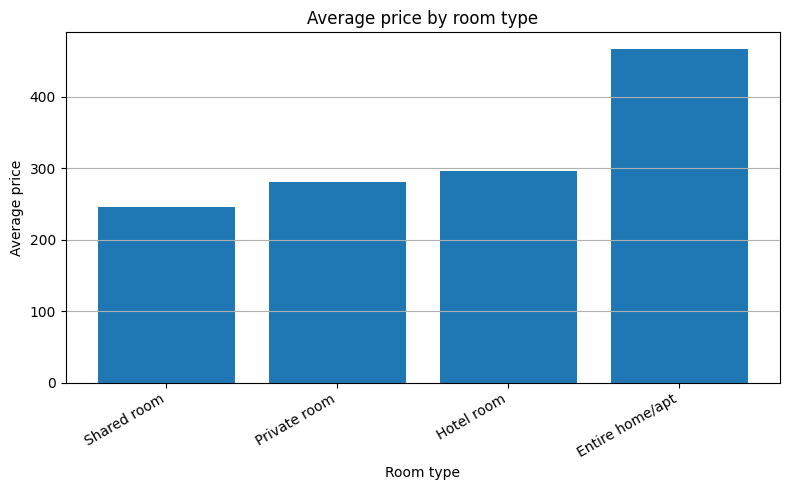

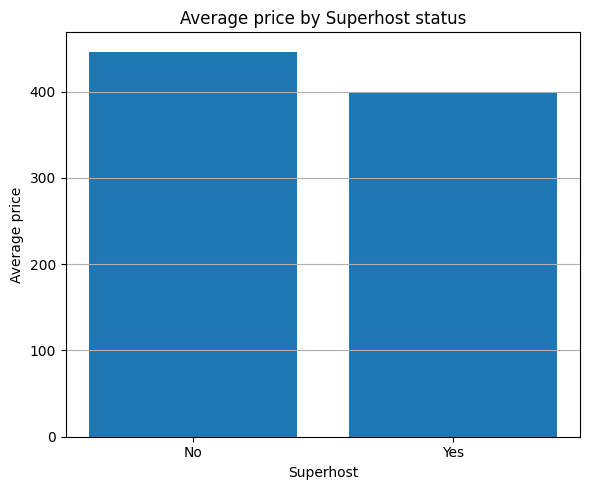

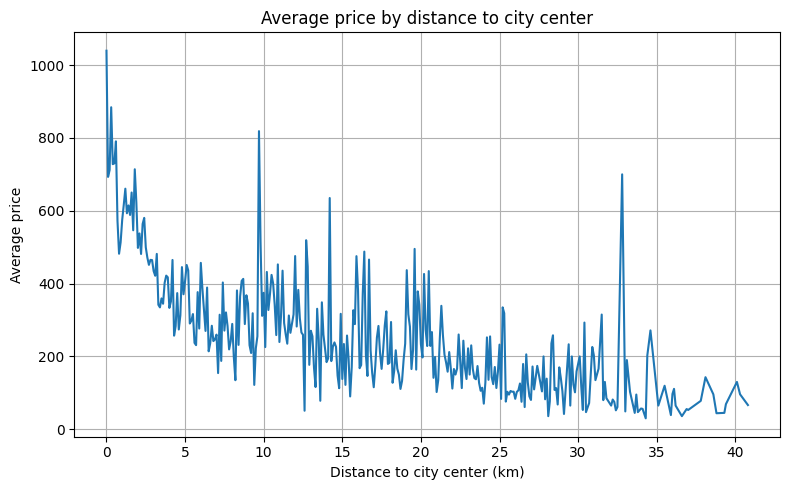

In [56]:

df_plot = df[['room_type', 'host_is_superhost', 'distance_to_city_center', 'price']].dropna().copy()

room_price = df_plot.groupby('room_type', observed=False)['price'].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(room_price.index.astype(str), room_price.values)
plt.xlabel('Room type')
plt.ylabel('Average price')
plt.title('Average price by room type')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

superhost_price = df_plot.groupby('host_is_superhost', observed=False)['price'].mean().reset_index()
superhost_price['host_is_superhost'] = superhost_price['host_is_superhost'].map({0: 'No', 1: 'Yes'})

plt.figure(figsize=(6, 5))
plt.bar(superhost_price['host_is_superhost'], superhost_price['price'])
plt.xlabel('Superhost')
plt.ylabel('Average price')
plt.title('Average price by Superhost status')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

distance_plot = df_plot[['distance_to_city_center', 'price']].copy()
distance_plot = distance_plot.sort_values('distance_to_city_center')

distance_plot['distance_round'] = distance_plot['distance_to_city_center'].round(1)
distance_price = distance_plot.groupby('distance_round', observed=False)['price'].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(distance_price['distance_round'], distance_price['price'])
plt.xlabel('Distance to city center (km)')
plt.ylabel('Average price')
plt.title('Average price by distance to city center')
plt.grid(True)
plt.tight_layout()
plt.show()

## Assumptions testing 

#### Heteroskedasticity

In [57]:
def heteroskedasticity_test(model):
    _, pval, _, _ = het_breuschpagan(model.resid, model.model.exog)
    print(f"p-value = {pval}")
    
    if pval < 0.05:
        print("Heteroskedasticity\n")
    else:
        print("Homoscedasticity\n")


heteroskedasticity_test(price_model)

p-value = 7.1862320635312165e-65
Heteroskedasticity



#### Linearity

In [58]:
def linearity_test(model):
    _, pval = sm.stats.linear_rainbow(model)
    print(f"p-value = {pval}")
    
    if pval < 0.05:
        print("Bad linearity\n")
    else:
        print("Good linearity\n")

linearity_test(price_model)

p-value = 4.0688140222872607e-11
Bad linearity



#### No Perfect Collinearity

In [59]:
def vif_test(model):
    X = model.model.exog
    names = model.model.exog_names
    
    vif_data = pd.DataFrame({
        "Variable": names,
        "VIF": [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    })
    
    vif_data = vif_data[vif_data["Variable"] != "const"]
    
    print(vif_data, "\n")
    
    if vif_data["VIF"].max() > 10:
        print("Multicollinearity detected\n")
    else:
        print("No serious multicollinearity\n")


vif_test(price_model)

                     Variable        VIF
1                   bathrooms   1.469617
2                    bedrooms   2.138827
3                        beds   1.900782
4              minimum_nights   1.036064
5            instant_bookable   1.106061
6                   occupancy   1.047582
7   room_type_Entire home/apt  25.023775
8        room_type_Hotel room   1.651017
9      room_type_Private room  24.733428
10  host_total_listings_count   1.016393
11          host_is_superhost   1.159238
12       review_scores_rating   1.083504
13          reviews_last_year   1.175868
14    distance_to_city_center   1.064685 

Multicollinearity detected



#### No Serial Correlation

In [60]:
def durbin_watson_test(model):
    dw_stat = durbin_watson(model.resid)
    print(f"DW = {dw_stat}")
    if dw_stat < 1.5:
        print("Positive\n")
    elif dw_stat > 2.5:
        print("Negative\n")
    else:
        print("No autocorrelation\n")

durbin_watson_test(price_model)

DW = 1.9575916367300257
No autocorrelation



#### Normality

In [61]:
def normality_test(model):
    resid = model.resid
    resid_std = (resid - np.mean(resid)) / np.std(resid)
    
    stat, pval = kstest(resid_std, 'norm')
    print(f"p-value = {pval}")
    
    if pval < 0.05:
        print("Residuals are NOT normal\n")
    else:
        print("Residuals are normal\n")


normality_test(price_model)

p-value = 5.5632984669220256e-18
Residuals are NOT normal

